In [1]:
import os
import h5py
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.preprocessing import normalize

# 1. Configuration & Data Preparation

In [2]:
parent_dir = r"W:\pathologie\bioinfo-archive\UK_Augsburg_Claus\KristianUnger\TitanFeatures\20x_512px_0px_overlap\slide_features_titan"
h5_key = "features"
df_path = r"W:\pathologie\bioinfo-archive\UK_Augsburg_Claus\KristianUnger\sample_info_KU_curated_120226.xlsx"
df1 = pd.read_excel(df_path)
df = pd.read_excel(df_path, sheet_name='sample_info_curated')
df = df.dropna(subset=['scan_name']).reset_index(drop=True)
df

,file_name_original,file_name,plate,position,sample_name,slide_name,scan_name,tif_name,slide_id,exists,...,Art_event,type_event,EFS_years,EFS_days,Death_disease,Date_of_death,OS_days,LastFollowup,date_of_LFU,Methylierungsgruppe
0,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,plate1,A2,1-T,T/1999/149,slide-2025-10-29T08-13-45-R1-S1.mrxs,slide-2025-10-29T08-13-45-R1-S1.ome.tif,slide-2025-10-29T08-13-45-R1-S1,slide-2025-10-29T08-13-45-R1-S1,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,2.0,2009-08-20 00:00:00,3
1,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,plate1,A4,2-b-N,T/2011/1450-b,slide-2025-10-29T08-25-47-R1-S2.mrxs,slide-2025-10-29T08-25-47-R1-S2.ome.tif,slide-2025-10-29T08-25-47-R1-S2,slide-2025-10-29T08-25-47-R1-S2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,plate1,A3,2-b-T,T/2011/1450-b,slide-2025-10-29T08-25-47-R1-S2.mrxs,slide-2025-10-29T08-25-47-R1-S2.ome.tif,slide-2025-10-29T08-25-47-R1-S2,slide-2025-10-29T08-25-47-R1-S2,...,9,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,x
3,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,plate1,A6,2-d-T,T/2011/1450-d,slide-2025-10-29T08-35-06-R1-S3.mrxs,slide-2025-10-29T08-35-06-R1-S3.ome.tif,slide-2025-10-29T08-35-06-R1-S3,slide-2025-10-29T08-35-06-R1-S3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,plate1,A7,3-N,NaN,slide-2025-10-29T08-54-08-R1-S5.mrxs,slide-2025-10-29T08-54-08-R1-S5.ome.tif,slide-2025-10-29T08-54-08-R1-S5,slide-2025-10-29T08-54-08-R1-S5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,plate2,G5,76-T,KT/2008/1362-1,slide-2025-10-30T16-08-37-R2-S9.mrxs,slide-2025-10-30T16-08-37-R2-S9.ome.tif,slide-2025-10-30T16-08-37-R2-S9,slide-2025-10-30T16-08-37-R2-S9,...,01/2009 1.Lokalrezidiv links mit bipulmonale M...,3.0,0.383562,140.0,2.0,2010-08-28 00:00:00,729.0,2.0,2010-08-28 00:00:00,x
122,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,plate2,G6,77-T,KT/2008/1365,slide-2025-10-30T16-26-23-R2-S10.mrxs,slide-2025-10-30T16-26-23-R2-S10.ome.tif,slide-2025-10-30T16-26-23-R2-S10,slide-2025-10-30T16-26-23-R2-S10,...,9,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1
123,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,plate2,G7,78-N,NaN,slide-2025-10-30T16-36-42-R2-S11.mrxs,slide-2025-10-30T16-36-42-R2-S11.ome.tif,slide-2025-10-30T16-36-42-R2-S11,slide-2025-10-30T16-36-42-R2-S11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
124,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,plate2,G8,78-T,KT/2008/956-1,slide-2025-10-30T16-36-42-R2-S11.mrxs,slide-2025-10-30T16-36-42-R2-S11.ome.tif,slide-2025-10-30T16-36-42-R2-S11,slide-2025-10-30T16-36-42-R2-S11,...,9,NaN,NaN,NaN,1.0,,NaN,1.0,NaN,3


# 2. Extract Slide-Level Embeddings

In [3]:
embeddings = []
valid_indices = []
scan_names = []
pat_ids = []
sample_names = []

print("Extracting embeddings from .h5 files...")
for idx, row in df.iterrows():
    try:
        scan_name = row['scan_name'][:-5]  # remove .mrxs extension
    except Exception as e:
        print(e)
    pat_id = str(row['ID_patient']) + scan_name.split("-")[-1]

    file_name = f"{scan_name}.h5" if not scan_name.endswith('.h5') else scan_name
    h5_path = os.path.join(parent_dir, file_name)

    # Check if file exists to prevent pipeline crashes
    if os.path.exists(h5_path):
        try:
            with h5py.File(h5_path, 'r') as f:
                vector = f[h5_key][:]
                # Flatten to 1D if necessary
                if vector.ndim > 1:
                    vector = np.squeeze(vector)

                if scan_name not in scan_names and row['sample_type'] == 'tumor':
                    embeddings.append(vector)
                    valid_indices.append(idx)
                    scan_names.append(scan_name)
                    pat_ids.append(pat_id)
                    sample_names.append(row['sample_name'])
                else:
                    print(f"repeated scan: {scan_name}")

        except Exception as e:
            print(f"Error reading {file_name}: {e}")
    else:
        print(f"Warning: Missing file for {scan_name}. Skipping.")

Extracting embeddings from .h5 files...
repeated scan: slide-2025-10-29T08-25-47-R1-S2
repeated scan: slide-2025-10-29T08-54-08-R1-S5
repeated scan: slide-2025-10-29T09-36-38-R1-S9
repeated scan: slide-2025-10-29T09-59-05-R1-S11
repeated scan: slide-2025-10-29T10-05-04-R1-S12
repeated scan: slide-2025-10-29T10-13-41-R1-S13
repeated scan: slide-2025-10-29T10-40-37-R1-S17
repeated scan: slide-2025-10-29T10-48-42-R1-S18
repeated scan: slide-2025-10-29T10-57-56-R1-S19
repeated scan: slide-2025-10-29T11-07-05-R1-S20
repeated scan: slide-2025-10-29T11-12-45-R1-S21
repeated scan: slide-2025-10-29T11-22-41-R1-S22
repeated scan: slide-2025-10-29T11-42-04-R1-S24
repeated scan: slide-2025-10-29T12-03-10-R1-S1
repeated scan: slide-2025-10-29T12-13-33-R1-S2
repeated scan: slide-2025-10-29T12-22-43-R1-S3
repeated scan: slide-2025-10-29T12-27-39-R1-S4
repeated scan: slide-2025-10-29T13-01-30-R1-S8
repeated scan: slide-2025-10-29T13-07-19-R1-S9
repeated scan: slide-2025-10-29T13-37-13-R1-S13
repeated 

In [4]:
# Create the final feature matrix
X = np.vstack(embeddings)

# Create a filtered dataframe that strictly matches the successfully loaded embeddings
df_valid = df.loc[valid_indices].reset_index(drop=True)

print(f"Successfully loaded {X.shape[0]} slides with {X.shape[1]} dimensions.")

Successfully loaded 84 slides with 768 dimensions.


# 3. Compute Distance and Linkage

In [5]:
print("Computing hierarchical linkage...")
# Normalize each embedding vector individually to unit L2 norm (axis=1)
X = normalize(X, norm='l2', axis=1)
diiiiistance = 'euclidean'
distance_matrix = pdist(X, metric=diiiiistance)
# Precomputing linkage is highly recommended for large datasets to save memory
Z = linkage(distance_matrix, method='average')

Computing hierarchical linkage...


# 4. Map Metadata to Colors

In [6]:
print("Generating metadata color annotations...")
row_colors_df = pd.DataFrame(index=df_valid.index)

# -- Mapping TP53e --
TP53 = df_valid['TP53'].unique()
palette_TP53 = sns.color_palette("Set1", len(TP53))
lut_TP53 = dict(zip(TP53, palette_TP53))
row_colors_df['TP53'] = df_valid['TP53'].map(lut_TP53)


COG_stadium = df_valid['COG_stadium'].unique()
lut_COG_stadium = dict(zip(COG_stadium, sns.color_palette("Pastel1", len(COG_stadium))))
row_colors_df['COG_stadium'] = df_valid['COG_stadium'].map(lut_COG_stadium)


event = df_valid['Event'].unique()
lut_event = dict(zip(event, sns.color_palette("Pastel2", len(event))))
row_colors_df['Event'] = df_valid['Event'].map(lut_event)


diagnoses = df_valid['Diagnosis'].unique()
lut_diagnoses = dict(zip(diagnoses, sns.color_palette("Pastel1", len(diagnoses))))
row_colors_df['Diagnosis'] = df_valid['Diagnosis'].map(lut_diagnoses)


# # -- Mapping Staining Quality (Optional second column) --
# if 'staining_quality' in df_valid.columns:
#     quality_types = df_valid['staining_quality'].unique()
#     palette_quality = sns.color_palette("Pastel1", len(quality_types))
#     lut_quality = dict(zip(quality_types, palette_quality))
#     row_colors_df['Stain Quality'] = df_valid['staining_quality'].map(lut_quality)
df_valid

Generating metadata color annotations...


,file_name_original,file_name,plate,position,sample_name,slide_name,scan_name,tif_name,slide_id,exists,...,Art_event,type_event,EFS_years,EFS_days,Death_disease,Date_of_death,OS_days,LastFollowup,date_of_LFU,Methylierungsgruppe
0,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,plate1,A2,1-T,T/1999/149,slide-2025-10-29T08-13-45-R1-S1.mrxs,slide-2025-10-29T08-13-45-R1-S1.ome.tif,slide-2025-10-29T08-13-45-R1-S1,slide-2025-10-29T08-13-45-R1-S1,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,2.0,2009-08-20 00:00:00,3
1,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,plate1,A3,2-b-T,T/2011/1450-b,slide-2025-10-29T08-25-47-R1-S2.mrxs,slide-2025-10-29T08-25-47-R1-S2.ome.tif,slide-2025-10-29T08-25-47-R1-S2,slide-2025-10-29T08-25-47-R1-S2,...,9,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,x
2,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,plate1,A6,2-d-T,T/2011/1450-d,slide-2025-10-29T08-35-06-R1-S3.mrxs,slide-2025-10-29T08-35-06-R1-S3.ome.tif,slide-2025-10-29T08-35-06-R1-S3,slide-2025-10-29T08-35-06-R1-S3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,plate1,A8,3-T,T/2013/785,slide-2025-10-29T08-54-08-R1-S5.mrxs,slide-2025-10-29T08-54-08-R1-S5.ome.tif,slide-2025-10-29T08-54-08-R1-S5,slide-2025-10-29T08-54-08-R1-S5,...,9,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,x
4,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,plate1,A9,4-T,T/2013/569,slide-2025-10-29T09-04-19-R1-S6.mrxs,slide-2025-10-29T09-04-19-R1-S6.ome.tif,slide-2025-10-29T09-04-19-R1-S6,slide-2025-10-29T09-04-19-R1-S6,...,1.3. weitere Events . 25.02.14. 28.05.14,4.0,1.010959e+09,369.0,2.0,2015-07-01 00:00:00,901.0,2.0,NaN,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,plate2,G4,75-T,KT2008/1381,slide-2025-10-30T15-59-21-R2-S8.mrxs,slide-2025-10-30T15-59-21-R2-S8.ome.tif,slide-2025-10-30T15-59-21-R2-S8,slide-2025-10-30T15-59-21-R2-S8,...,9,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,x
80,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,plate2,G5,76-T,KT/2008/1362-1,slide-2025-10-30T16-08-37-R2-S9.mrxs,slide-2025-10-30T16-08-37-R2-S9.ome.tif,slide-2025-10-30T16-08-37-R2-S9,slide-2025-10-30T16-08-37-R2-S9,...,01/2009 1.Lokalrezidiv links mit bipulmonale M...,3.0,3.835616e-01,140.0,2.0,2010-08-28 00:00:00,729.0,2.0,2010-08-28 00:00:00,x
81,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,plate2,G6,77-T,KT/2008/1365,slide-2025-10-30T16-26-23-R2-S10.mrxs,slide-2025-10-30T16-26-23-R2-S10.ome.tif,slide-2025-10-30T16-26-23-R2-S10,slide-2025-10-30T16-26-23-R2-S10,...,9,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1
82,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,20231106_OA2_AnMe_SA_ACCstudy_P003_21min_plate...,plate2,G8,78-T,KT/2008/956-1,slide-2025-10-30T16-36-42-R2-S11.mrxs,slide-2025-10-30T16-36-42-R2-S11.ome.tif,slide-2025-10-30T16-36-42-R2-S11,slide-2025-10-30T16-36-42-R2-S11,...,9,NaN,NaN,NaN,1.0,,NaN,1.0,NaN,3


# 5. Generate Clustermap Visualization

Plotting clustermap...


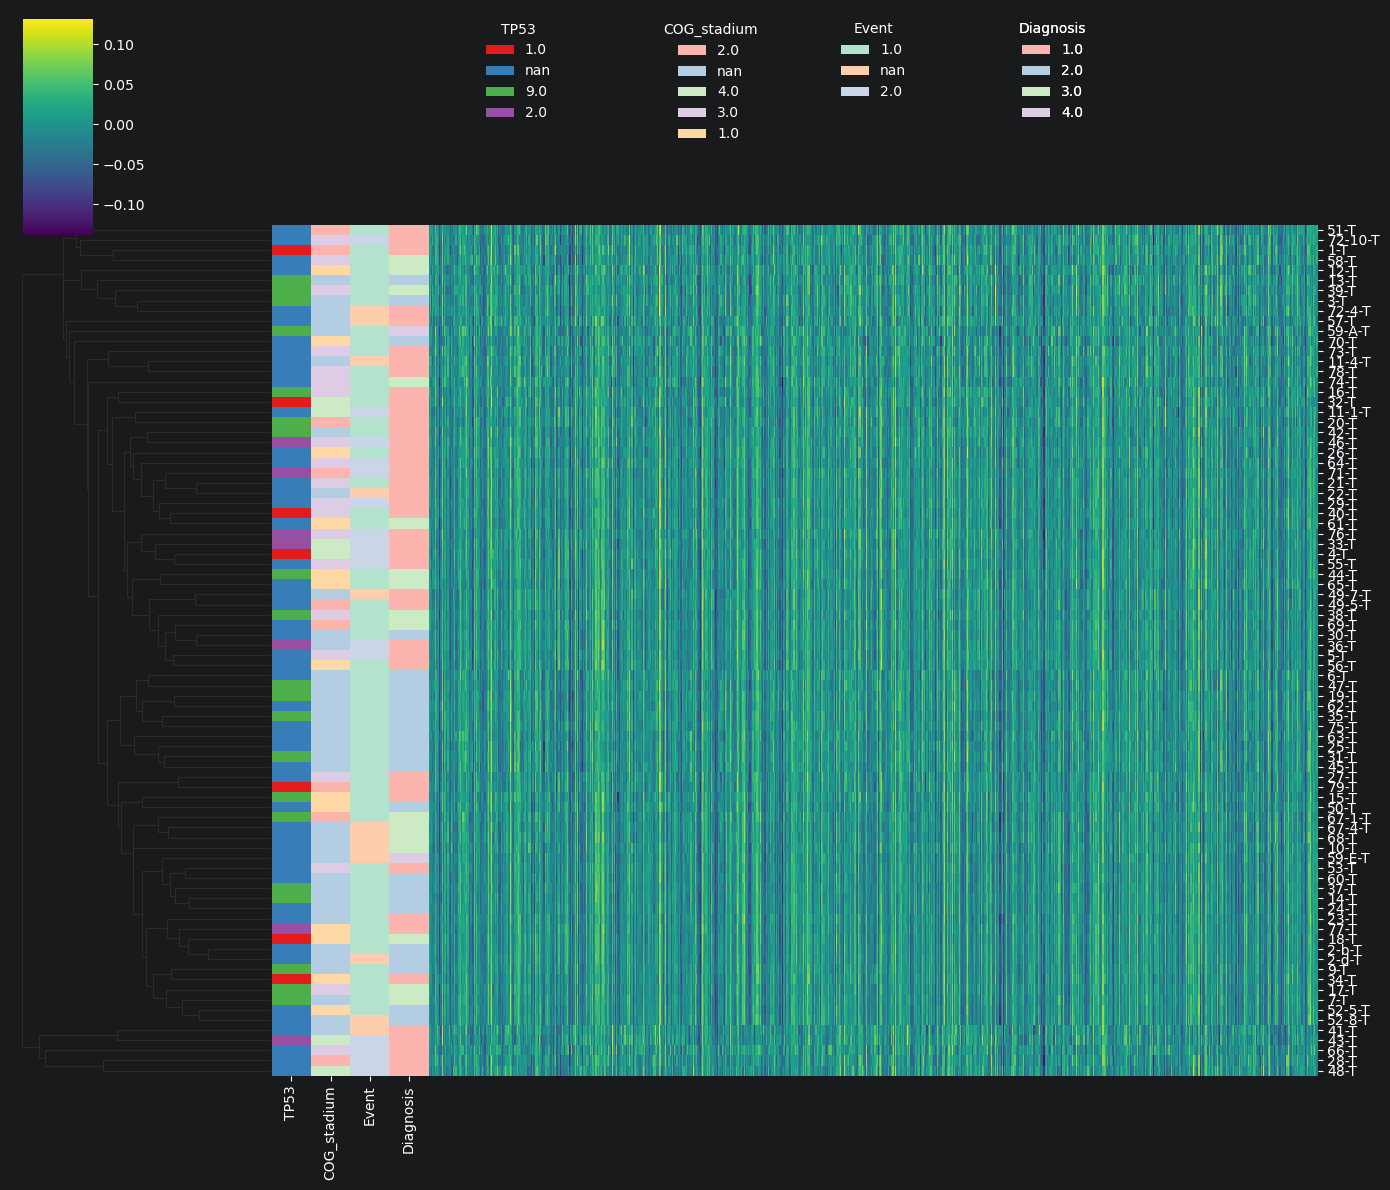

In [7]:
# Convert X into a DataFrame to align its index with row_colors_df
X_df = pd.DataFrame(X, index=df_valid.index)

print("Plotting clustermap...")
g = sns.clustermap(
    X_df,                         # Use the indexed DataFrame here instead of X
    row_linkage=Z,
    metric=diiiiistance,
    cmap="viridis",
    row_colors=row_colors_df,     # Indices now match perfectly
    figsize=(14, 12),
    xticklabels=False,
    yticklabels=df_valid['sample_name'].values,
    col_cluster=False
)

# Create a custom function to draw legends to keep the code clean
def add_custom_legend(ax, lut, title, x_position):
    # Create legend handles (colored boxes)
    handles = [Patch(facecolor=color, edgecolor='none', label=label)
               for label, color in lut.items()]

    # Add the legend to the plot
    legend = ax.legend(
        handles=handles,
        title=title,
        loc='upper left',
        bbox_to_anchor=(x_position, 1), # x_position pushes it to the right
        frameon=False
    )
    # Add the legend manually to the axis so it isn't overwritten by the next one
    ax.add_artist(legend)

# Apply the legends to the dendrogram axis
# Increment the X-coordinate (1.05, 1.25, 1.45) to space them out horizontally
add_custom_legend(g.ax_col_dendrogram, lut_TP53, "TP53", .05)
add_custom_legend(g.ax_col_dendrogram, lut_COG_stadium, "COG_stadium", .25)
add_custom_legend(g.ax_col_dendrogram, lut_event, "Event", .45)
add_custom_legend(g.ax_col_dendrogram, lut_diagnoses, "Diagnosis", .65)


output_filename = "wsi_hierarchical_clustering.pdf" # You can use .png, .pdf, .svg, or .jpg
g.savefig(output_filename, dpi=300, bbox_inches='tight')
plt.show()

Plotting clustermap...


NameError: name 'lut_tumor' is not defined

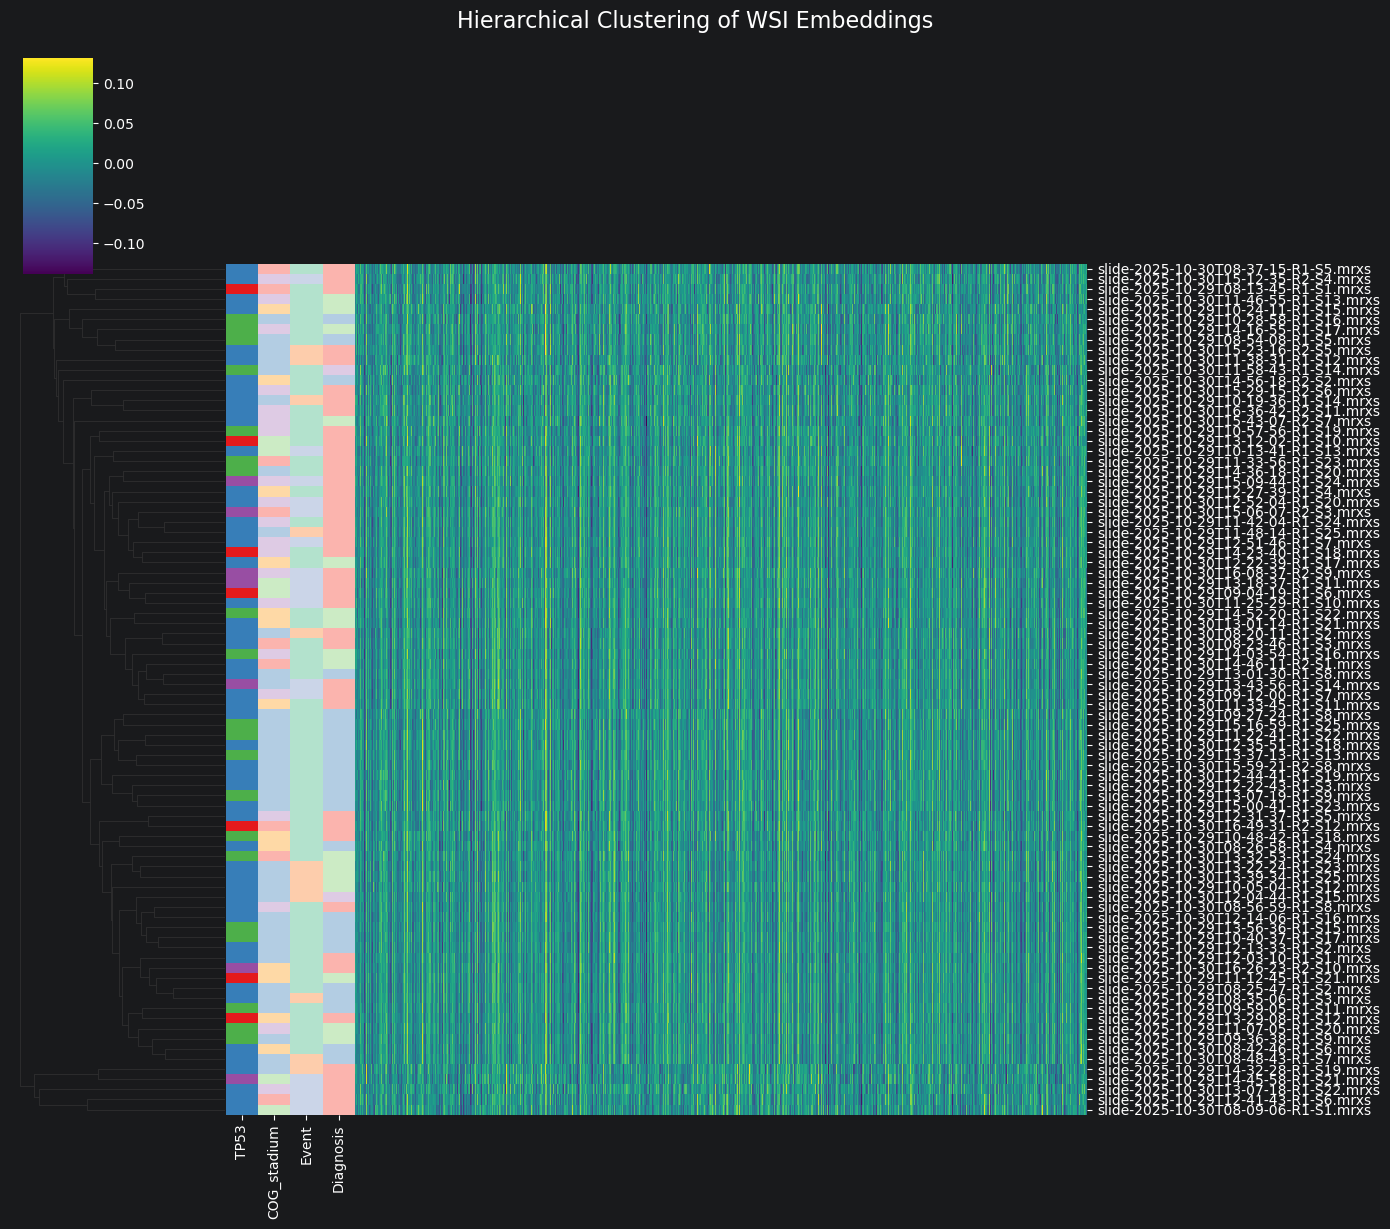

In [8]:
# Convert X into a DataFrame to align its index with row_colors_df
X_df = pd.DataFrame(X, index=df_valid.index)

print("Plotting clustermap...")
g = sns.clustermap(
    X_df,                         # Use the indexed DataFrame here instead of X
    row_linkage=Z,
    metric="cosine",
    cmap="viridis",
    row_colors=row_colors_df,     # Indices now match perfectly
    figsize=(14, 12),
    xticklabels=False,
    yticklabels=df_valid['scan_name'].values,
    col_cluster=False
)

# Set plot title
g.fig.suptitle("Hierarchical Clustering of WSI Embeddings", y=1.02, fontsize=16)

# Add custom legends for the metadata
for label, color in lut_tumor.items():
    g.ax_col_dendrogram.bar(0, 0, color=color, label=label, linewidth=0)

g.ax_col_dendrogram.legend(
    title="Sample Type",
    loc="center",
    bbox_to_anchor=(1.1, 0.8),
    frameon=False
)

plt.show()

In [ ]:
print("Plotting clustermap...")
g = sns.clustermap(
    X_df,
    row_linkage=Z,                # Keeps the precomputed row clustering
    metric="cosine",
    cmap="viridis",
    row_colors=row_colors_df,
    figsize=(16, 12),             # Increased width to accommodate x-axis labels
    xticklabels=True,             # CHANGED: This will display the column indices (0, 1, 2... N)
    yticklabels=df_valid['scan_name'].values,
    col_cluster=True              # CHANGED: This enables hierarchical clustering on the columns
)

# Set plot title
g.fig.suptitle("Hierarchical Clustering of WSI Embeddings (Rows and Columns)", y=1.02, fontsize=16)

# Add custom legends for the metadata
for label, color in lut_tumor.items():
    g.ax_col_dendrogram.bar(0, 0, color=color, label=label, linewidth=0)

g.ax_col_dendrogram.legend(
    title="Sample Type",
    loc="center",
    bbox_to_anchor=(1.1, 0.8),
    frameon=False
)

# Optional: Rotate the x-axis labels if they overlap
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=8)

plt.show()